<a href="https://colab.research.google.com/github/rkuo2000/AI-exercise/blob/main/colab/EuroSAT_ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EuroSAT ResNet18 in PyTorch

## Dataset: [EuroSAT](https://github.com/phelber/EuroSAT)
### [EuroSAT_RGB.zip](https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1)

![](https://github.com/phelber/EuroSAT/raw/master/eurosat_overview_small.jpg?raw=true)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Dataset Loader

In [3]:
import torch
from torchvision import datasets
from torch.utils.data import random_split, DataLoader

mean = (0.1307,0.1307,0.1307)
std = (0.3081,0.3081,0.3081)

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
    ])

# 1. Load the dataset
dataset = datasets.EuroSAT(root='./data', download=True, transform=transform) # Replace 'transform' with your actual transform

# 2. Define the split sizes
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size

# 3. Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 4. Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

100%|██████████| 94.3M/94.3M [00:01<00:00, 91.6MB/s]


## Build Model

In [4]:
# Load a pretrained ResNet-18 model
from torchvision import models

#resnet18 = models.resnet18() # without pre-trained weights (optim.AdamW)
#resnet18 = models.resnet18(weights="ResNet18_Weights.DEFAULT") # with pre-trained ImageNet default weights (optim.Adam)
resnet18 = models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1") # with pre-trained ImageNet1K v1 weights (optim.Adam)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


## Train Model

In [5]:
model = resnet18.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
def train(model, device, train_loader, optimizer, epoch, log_interval):
    total_step = len(train_loader)
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if i % log_interval == 0:
            print(f'Epoch [{epoch}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')

In [7]:
# Evaluation
def valid(model, device, val_loader):

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in val_loader:
            outputs = model(images.to(device))
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()

    print(f'Valid Accuracy: {100 * correct / total}%')

In [8]:
num_epoch = 15

for epoch in range(1, num_epoch + 1):
    # Ensure train() and valid() return their respective epoch loss/metrics
    train(model, device, train_loader, optimizer, epoch, 100)
    valid(model, device, val_loader)

Epoch [1], Step [1/338], Loss: 12.7711
Epoch [1], Step [101/338], Loss: 0.1948
Epoch [1], Step [201/338], Loss: 0.3839
Epoch [1], Step [301/338], Loss: 0.1392
Valid Accuracy: 92.92592592592592%
Epoch [2], Step [1/338], Loss: 0.1532
Epoch [2], Step [101/338], Loss: 0.1184
Epoch [2], Step [201/338], Loss: 0.1855
Epoch [2], Step [301/338], Loss: 0.3954
Valid Accuracy: 78.03703703703704%
Epoch [3], Step [1/338], Loss: 0.1771
Epoch [3], Step [101/338], Loss: 0.0339
Epoch [3], Step [201/338], Loss: 0.1819
Epoch [3], Step [301/338], Loss: 0.1944
Valid Accuracy: 91.12962962962963%
Epoch [4], Step [1/338], Loss: 0.1930
Epoch [4], Step [101/338], Loss: 0.0465
Epoch [4], Step [201/338], Loss: 0.0462
Epoch [4], Step [301/338], Loss: 0.1137
Valid Accuracy: 94.64814814814815%
Epoch [5], Step [1/338], Loss: 0.2646
Epoch [5], Step [101/338], Loss: 0.3144
Epoch [5], Step [201/338], Loss: 0.1180
Epoch [5], Step [301/338], Loss: 0.0924
Valid Accuracy: 93.44444444444444%
Epoch [6], Step [1/338], Loss: 0.0

## Save Model

In [9]:
torch.save(model.state_dict(), "eurosat_resnet18.pt")

## Test Model

In [10]:
sample = next(iter(val_loader))
imgs, lbls = sample
len(lbls)

64

In [11]:
# first 10 predictions
actual_y = lbls[:10].numpy()
print(actual_y)

[9 4 5 2 0 7 0 1 1 0]


In [12]:
classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [13]:
imgs, lbls = imgs.to(device), lbls.to(device)
test_output = model(imgs[:10])

pred_y = torch.max(test_output, 1)[1].to('cpu').numpy()
print(f'Predict: {pred_y}')
print(f'Actual : {actual_y}')

print([classes[pred_y[x]] for x in range(10)])
print([classes[actual_y[x]] for x in range(10)])

Predict: [9 4 5 2 0 7 9 1 1 0]
Actual : [9 4 5 2 0 7 0 1 1 0]
['SeaLake', 'Industrial', 'Pasture', 'HerbaceousVegetation', 'AnnualCrop', 'Residential', 'SeaLake', 'Forest', 'Forest', 'AnnualCrop']
['SeaLake', 'Industrial', 'Pasture', 'HerbaceousVegetation', 'AnnualCrop', 'Residential', 'AnnualCrop', 'Forest', 'Forest', 'AnnualCrop']


## Show test images (normalized)

### Inverse Normalize Image

In [14]:
class InverseNormalize(transforms.Normalize):
    def __init__(self, mean, std):
        # The inverse operation for Normalize requires multiplying by std and adding mean.
        # So, we effectively "normalize" with negative mean/std and inverse std.
        # This is equivalent to: (x - (-mean/std)) / (1/std) = (x + mean/std) * std = x*std + mean
        mean = [-m / s for m, s in zip(mean, std)]
        std = [1 / s for s in std]
        super().__init__(mean, std)

inverse_normalize_transform = InverseNormalize(mean=mean, std=std)

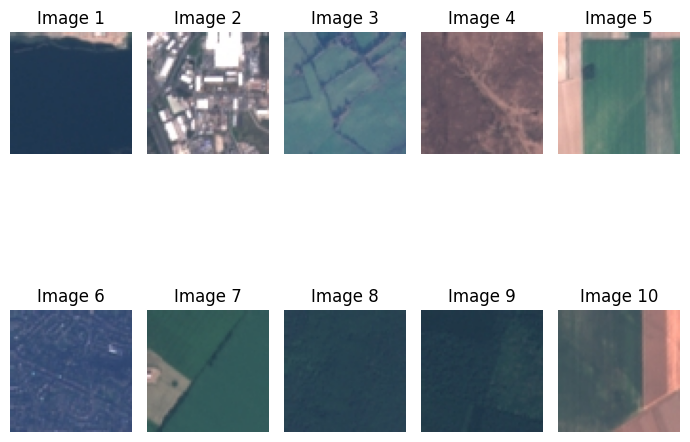

In [15]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

num_row = 2
num_col = 5

fig, axes = plt.subplots(num_row, num_col, figsize=(7, 7)) # Adjust figsize as needed
axes = axes.flatten()

for i, img in enumerate(imgs):
    # inverse normalized image
    img = inverse_normalize_transform(img)
    # convert Tensor-image to PIL-image
    to_pil_image_transform = transforms.ToPILImage()
    image = to_pil_image_transform(img)

    if (i< 2*5):
        axes[i].imshow(image) # Use 'gray' colormap for grayscale images
        axes[i].set_title(f'Image {i+1}')
        axes[i].axis('off') # Turn off axis labels and ticks for cleaner display

plt.tight_layout()
plt.show()